In [ ]:
import json
from pathlib import Path
from typing import Any, Dict, Optional

import numpy as np
import pandas as pd

# RESULTS_PATH = Path("/home/akapociu/ift/interactiondynamics/results/ds_sweep_results_6ep_3seed.jsonl")
SUMMARY_PATH = Path("/home/akapociu/ift/interactiondynamics/results/ds_sweep_summary_6ep_3seed.jsonl")

EXPECTED_SEEDS = 3

In [238]:
def safe_get(d: Dict[str, Any], *keys, default=None):
    cur = d
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur


def extract_test_mrr(row):
    return safe_get(row, "best_snapshot", "test", "mrr", default=None)


def extract_walltime(row):
    return row.get("wall_sec", None)

def parse_run_string(run_name: str) -> Dict[str, Any]:
    """
    Example:
    Wikipedia__agg=ift|update=ift_update|do=0.0|sdo=0.0|time=False|softplus|dt=0.05|gamma=0.0|k0=1.0|cap=none
    or
    Wikipedia__agg=sum|update=tgn_gru|do=0.0|sdo=0.0|time=False
    """
    out = {
        "aggregator": None,
        "update": None,
        "dropout": None,
        "scorer_dropout": None,
        "time_features": None,
        "ift_kappa_param": None,
        "ift_dt": None,
        "ift_gamma": None,
        "ift_kappa_init": None,
        "ift_kappa_cap": None,
        "ift_kappa_max": None,
    }

    if run_name is None:
        return out

    if "__" in run_name:
        _, run_body = run_name.split("__", 1)
    else:
        run_body = run_name

    parts = run_body.split("|")
    for part in parts:
        if "=" in part:
            k, v = part.split("=", 1)

            if k == "agg":
                out["aggregator"] = v
            elif k == "update":
                out["update"] = v
            elif k == "do":
                out["dropout"] = float(v)
            elif k == "sdo":
                out["scorer_dropout"] = float(v)
            elif k == "time":
                out["time_features"] = (v == "True")
            elif k == "dt":
                out["ift_dt"] = float(v)
            elif k == "gamma":
                out["ift_gamma"] = float(v)
            elif k == "k0":
                out["ift_kappa_init"] = float(v)
            elif k == "cap":
                if v == "none":
                    out["ift_kappa_cap"] = False
                    out["ift_kappa_max"] = None
                else:
                    out["ift_kappa_cap"] = True
                    try:
                        out["ift_kappa_max"] = float(v)
                    except ValueError:
                        out["ift_kappa_max"] = v
        else:
            if part in {"softplus", "exp"}:
                out["ift_kappa_param"] = part

    return out

In [239]:
def load_summary_jsonl(path: Path) -> pd.DataFrame:
    rows = []

    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            row = json.loads(line)

            dataset = row.get("dataset", None)
            run_name = row.get("name", row.get("run", None))
            seed = row.get("seed", None)
            best_val_mrr = row.get("best_val_mrr", None)
            best_epoch = row.get("best_epoch", None)
            test_mrr = extract_test_mrr(row)
            wall_sec = extract_walltime(row)

            parsed = parse_run_string(run_name)

            clean = {
                "dataset": dataset,
                "run_name": run_name,
                "seed": seed,
                "best_val_mrr": best_val_mrr,
                "best_test_mrr": test_mrr,
                "wall_sec": wall_sec,
                "best_epoch": best_epoch,

                # best snapshot metrics
                "best_val_early_mrr": safe_get(row, "best_snapshot", "val", "early_mrr", default=None),
                "best_val_late_mrr": safe_get(row, "best_snapshot", "val", "late_mrr", default=None),
                "best_test_early_mrr": safe_get(row, "best_snapshot", "test", "early_mrr", default=None),
                "best_test_late_mrr": safe_get(row, "best_snapshot", "test", "late_mrr", default=None),

                # final snapshot metrics
                "final_val_mrr": safe_get(row, "final_snapshot", "val", "mrr", default=None),
                "final_test_mrr": safe_get(row, "final_snapshot", "test", "mrr", default=None),
                "final_val_early_mrr": safe_get(row, "final_snapshot", "val", "early_mrr", default=None),
                "final_val_late_mrr": safe_get(row, "final_snapshot", "val", "late_mrr", default=None),
                "final_test_early_mrr": safe_get(row, "final_snapshot", "test", "early_mrr", default=None),
                "final_test_late_mrr": safe_get(row, "final_snapshot", "test", "late_mrr", default=None),

                **parsed,
            }
            rows.append(clean)

    return pd.DataFrame(rows)


summary_df = load_summary_jsonl(SUMMARY_PATH)
summary_df["overfit_gap"] = summary_df["best_test_mrr"] - summary_df["final_test_mrr"]
summary_df["peaked_early"] = summary_df["best_epoch"] <= 2
summary_df["completed_run"] = summary_df["final_test_mrr"].notna()
summary_df.shape

(295, 31)

In [240]:
wiki_df   = summary_df[summary_df["dataset"] == "Wikipedia"].copy()
reddit_df = summary_df[summary_df["dataset"] == "Reddit"].copy()
mooc_df   = summary_df[summary_df["dataset"] == "MOOC"].copy()
lastfm_df = summary_df[summary_df["dataset"] == "LastFM"].copy()

dataset_dfs = {
    "Wikipedia": wiki_df,
    "Reddit": reddit_df,
    "MOOC": mooc_df,
    "LastFM": lastfm_df,
}

for name, df in dataset_dfs.items():
    print(name, df.shape)

Wikipedia (75, 31)
Reddit (73, 31)
MOOC (75, 31)
LastFM (72, 31)


In [241]:
def build_dataset_model_ranking(df: pd.DataFrame, expected_seeds: int = 3) -> pd.DataFrame:
    out = (
        df.groupby(["dataset", "aggregator", "update"], dropna=False)
          .agg(
              n_seeds=("seed", "nunique"),
              avg_val_mrr=("best_val_mrr", "mean"),
              std_val_mrr=("best_val_mrr", "std"),
              mean_test_mrr=("best_test_mrr", "mean"),
              std_test_mrr=("best_test_mrr", "std"),
              mean_overfit_gap=("overfit_gap", "mean"),
              peaked_early_rate=("peaked_early", "mean"),
              avg_early_val_mrr=("best_val_early_mrr", "mean"),
              avg_late_val_mrr=("best_val_late_mrr", "mean"),
              avg_early_test_mrr=("best_test_early_mrr", "mean"),
              avg_late_test_mrr=("best_test_late_mrr", "mean"),
              wall_sec_mean=("wall_sec", "mean"),
              wall_sec_std=("wall_sec", "std"),
          )
          .reset_index()
    )

    out["did_complete"] = out["n_seeds"] == expected_seeds

    out = out.sort_values(
        by=["avg_val_mrr", "mean_test_mrr"],
        ascending=[False, False]
    ).reset_index(drop=True)

    out["rank_in_dataset"] = np.arange(1, len(out) + 1)

    return out[
        [
            "dataset",
            "aggregator",
            "update",
            "rank_in_dataset",
            "avg_val_mrr",
            "std_val_mrr",
            "mean_test_mrr",
            "std_test_mrr",
            "mean_overfit_gap",
            "peaked_early_rate",
            "avg_early_val_mrr",
            "avg_late_val_mrr",
            "avg_early_test_mrr",
            "avg_late_test_mrr",
            "wall_sec_mean",
            "wall_sec_std",
            "n_seeds",
            "did_complete",
        ]
    ]

In [242]:
rank_all_by_dataset = {
    ds: build_dataset_model_ranking(df, expected_seeds=EXPECTED_SEEDS)
    for ds, df in dataset_dfs.items()
}

wiki_rank_all   = rank_all_by_dataset["Wikipedia"]
reddit_rank_all = rank_all_by_dataset["Reddit"]
mooc_rank_all   = rank_all_by_dataset["MOOC"]
lastfm_rank_all = rank_all_by_dataset["LastFM"]

display(wiki_rank_all)
display(reddit_rank_all)
display(mooc_rank_all)
display(lastfm_rank_all)

,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
0,Wikipedia,ift,tgn_gru,1,0.860372,0.001454,0.866016,0.002074,0.003169,0.333333,0.897637,0.856646,0.910628,0.861642,43.048286,0.411768,3,True
1,Wikipedia,sum,hopfield_update,2,0.860003,0.001474,0.855444,0.004152,0.027795,0.333333,0.848459,0.861158,0.872381,0.853783,389.023909,0.077532,3,True
2,Wikipedia,ift,hopfield_update,3,0.857577,0.003452,0.863980,0.002124,0.012513,0.000000,0.889446,0.854390,0.906051,0.859855,397.996660,0.278399,3,True
3,Wikipedia,settransformer,hopfield_update,4,0.841935,0.013559,0.839650,0.014128,0.000000,0.000000,0.838232,0.842305,0.860291,0.837626,447.884442,0.116837,3,True
4,Wikipedia,sum,tgn_gru,5,0.841612,0.011573,0.839917,0.011380,0.079266,0.333333,0.840701,0.841703,0.865282,0.837430,32.047713,0.362897,3,True
5,Wikipedia,settransformer,tgn_gru,6,0.837348,0.012149,0.837820,0.011854,0.022294,0.000000,0.839373,0.837145,0.857524,0.835888,67.174628,0.737070,3,True
6,Wikipedia,deepsets,hopfield_update,7,0.837123,0.005219,0.833010,0.009174,0.016654,0.000000,0.837531,0.837083,0.855564,0.830799,393.655440,0.137987,3,True
7,Wikipedia,hopfield,tgn_gru,8,0.825241,0.001610,0.825930,0.000900,0.005238,0.000000,0.835197,0.824246,0.853171,0.823260,45.966172,0.312473,3,True
8,Wikipedia,hopfield,hopfield_update,9,0.822390,0.008600,0.820832,0.006123,0.056089,0.666667,0.827387,0.821891,0.851376,0.817837,425.870684,0.067850,3,True
9,Wikipedia,deepsets,tgn_gru,10,0.816450,0.016194,0.804569,0.022176,0.017730,0.000000,0.837523,0.814343,0.838816,0.801211,37.859519,0.441866,3,True


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
0,Reddit,deepsets,ift_update,1,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,54.240344,0.043507,3,True
1,Reddit,ift,tgn_gru,2,0.939561,0.003510,0.940129,0.003214,0.002779,0.000000,0.929604,0.940557,0.935445,0.940588,50.313569,0.200224,3,True
2,Reddit,ift,hopfield_update,3,0.924985,0.005281,0.926777,0.003281,0.028831,0.000000,0.908321,0.926651,0.913298,0.928098,544.409674,0.217579,3,True
3,Reddit,ift,hnn,4,0.920888,0.006690,0.923994,0.005208,0.000493,0.666667,0.905253,0.922451,0.913325,0.925040,69.798048,0.451387,3,True
4,Reddit,ift,lnn,5,0.915876,0.001166,0.919047,0.001441,0.000000,0.000000,0.890930,0.918371,0.902858,0.920634,60.554952,0.581937,3,True
5,Reddit,deepsets,tgn_gru,6,0.913801,0.005084,0.912834,0.004072,0.002507,0.000000,0.874671,0.917714,0.870733,0.916962,48.917371,0.155240,3,True
6,Reddit,sum,hopfield_update,7,0.912975,0.001778,0.917124,0.001501,0.003973,0.000000,0.872853,0.916987,0.874623,0.921291,534.937039,0.322659,3,True
7,Reddit,sum,tgn_gru,8,0.911373,0.023626,0.914302,0.019669,0.060183,0.000000,0.858770,0.916633,0.862770,0.919355,42.802287,0.255747,3,True
8,Reddit,settransformer,tgn_gru,9,0.906216,0.000984,0.905529,0.001309,0.001025,0.333333,0.868936,0.909944,0.865765,0.909428,105.481663,0.172162,3,True
9,Reddit,hopfield,tgn_gru,10,0.902289,0.003738,0.903005,0.002994,0.001236,0.000000,0.837262,0.908791,0.845891,0.908604,61.920998,0.290080,3,True


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
0,MOOC,ift,tgn_gru,1,0.973237,0.009487,0.969200,0.011324,0.003778,0.333333,0.981601,0.972366,0.973164,0.968791,41.553625,0.206922,3,True
1,MOOC,settransformer,tgn_gru,2,0.966999,0.000421,0.960271,0.000391,-0.000595,0.333333,0.971018,0.966581,0.962621,0.960029,66.540998,0.676842,3,True
2,MOOC,sum,hopfield_update,3,0.966691,0.005852,0.963014,0.006783,0.002292,0.000000,0.966476,0.966713,0.955665,0.963771,234.856574,0.073969,3,True
3,MOOC,ift,hopfield_update,4,0.966239,0.005437,0.959932,0.007883,0.001416,0.666667,0.968997,0.965952,0.928066,0.963218,245.753235,0.283988,3,True
4,MOOC,deepsets,tgn_gru,5,0.966221,0.000998,0.956380,0.006551,-0.003303,0.333333,0.965211,0.966326,0.913013,0.960851,36.863621,0.092941,3,True
5,MOOC,deepsets,hopfield_update,6,0.964985,0.001416,0.958814,0.000970,0.007673,0.333333,0.965910,0.964889,0.936584,0.961105,238.213580,0.098411,3,True
6,MOOC,ift,ift_update,7,0.964978,0.000469,0.958428,0.001274,0.006531,0.333333,0.972167,0.964229,0.952296,0.959060,45.744883,0.137562,3,True
7,MOOC,sum,tgn_gru,8,0.963305,0.002914,0.957214,0.003726,0.005574,0.000000,0.961651,0.963478,0.918865,0.961167,32.535249,0.073817,3,True
8,MOOC,sum,hnn,9,0.962930,0.001413,0.955377,0.000925,-0.000614,0.333333,0.965535,0.962659,0.959868,0.954914,51.411779,0.822974,3,True
9,MOOC,hopfield,tgn_gru,10,0.962078,0.000373,0.954003,0.003104,0.002157,0.333333,0.962249,0.962061,0.950412,0.954374,45.802109,0.329830,3,True


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
0,LastFM,deepsets,hopfield_update,1,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2918.614064,2.078869,3,True
1,LastFM,deepsets,ift_update,2,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2492.739492,2.576855,3,True
2,LastFM,settransformer,ift_update,3,1.000000,0.000000,1.000000,0.000000,0.308878,1.000000,1.000000,1.000000,1.000000,1.000000,4075.042972,3.952480,3,True
3,LastFM,ift,tgn_gru,4,0.440791,0.005729,0.475079,0.002489,0.011910,0.333333,0.563941,0.440575,0.607373,0.474844,2513.622913,4.519212,3,True
4,LastFM,sum,tgn_gru,5,0.438207,0.002694,0.461794,0.006641,0.034385,0.666667,0.570156,0.437976,0.612006,0.461526,1995.287956,4.318327,3,True
5,LastFM,ift,hopfield_update,6,0.433506,0.004482,0.465878,0.004632,0.082716,0.333333,0.572150,0.433262,0.632469,0.465582,3204.043232,1.930860,3,True
6,LastFM,sum,hopfield_update,7,0.429999,0.010160,0.457073,0.010326,0.082428,0.333333,0.520519,0.429840,0.570732,0.456871,2818.689230,5.746378,3,True
7,LastFM,ift,ift_update,8,0.425462,0.000290,0.462959,0.000596,-0.000356,0.000000,0.560895,0.425224,0.630042,0.462662,2744.502441,2.743353,3,True
8,LastFM,hopfield,hopfield_update,9,0.413990,0.011281,0.443000,0.010516,0.031786,0.333333,0.541456,0.413767,0.561361,0.442790,3964.570646,6.895869,3,True
9,LastFM,hopfield,tgn_gru,10,0.397860,0.012964,0.427766,0.009140,0.007175,0.000000,0.572400,0.397554,0.642227,0.427385,2505.330206,0.690646,3,True


In [243]:
def build_filtered_ranking(
    df: pd.DataFrame,
    expected_seeds: int = 3,
    only_ift_aggregator: bool = False,
    only_ift_update: bool = False,
    only_ift_both: bool = False,
) -> pd.DataFrame:

    sub = df.copy()

    if only_ift_both:
        sub = sub[(sub["aggregator"] == "ift") & (sub["update"] == "ift_update")]
    elif only_ift_aggregator:
        sub = sub[sub["aggregator"] == "ift"]
    elif only_ift_update:
        sub = sub[sub["update"] == "ift_update"]

    out = (
        sub.groupby(["dataset", "aggregator", "update"], dropna=False)
           .agg(
                n_seeds=("seed", "nunique"),
                avg_val_mrr=("best_val_mrr", "mean"),
                std_val_mrr=("best_val_mrr", "std"),
                mean_test_mrr=("best_test_mrr", "mean"),
                std_test_mrr=("best_test_mrr", "std"),
                mean_overfit_gap=("overfit_gap", "mean"),
                peaked_early_rate=("peaked_early", "mean"),

                avg_early_val_mrr=("best_val_early_mrr", "mean"),
                avg_late_val_mrr=("best_val_late_mrr", "mean"),
                avg_early_test_mrr=("best_test_early_mrr", "mean"),
                avg_late_test_mrr=("best_test_late_mrr", "mean"),

                walltime_mean_sec=("wall_sec", "mean"),
                walltime_std_sec=("wall_sec", "std"),
            )
           .reset_index()
    )

    out["did_complete"] = out["n_seeds"] == expected_seeds

    out = out.sort_values(
        by=["avg_val_mrr", "mean_test_mrr"],
        ascending=[False, False]
    ).reset_index(drop=True)

    out["rank_in_dataset"] = np.arange(1, len(out) + 1)

    return out[
        [
            "dataset",
            "aggregator",
            "update",
            "rank_in_dataset",
            "avg_val_mrr",
            "std_val_mrr",
            "mean_test_mrr",
            "std_test_mrr",
            "mean_overfit_gap",
            "peaked_early_rate",
            "avg_early_val_mrr",
            "avg_late_val_mrr",
            "avg_early_test_mrr",
            "avg_late_test_mrr",
            "wall_sec_mean",
            "wall_sec_std",
            "n_seeds",
            "did_complete",
        ]
    ]

In [244]:
ift_tables_by_dataset = {}

for ds, full_table in rank_all_by_dataset.items():
    ift_tables_by_dataset[ds] = {
        "ift_aggregator_only": full_table[
            (full_table["aggregator"] == "ift") &
            (full_table["update"] != "ift_update")
        ].copy(),

        "ift_update_only": full_table[
            (full_table["update"] == "ift_update") &
            (full_table["aggregator"] != "ift")
        ].copy(),

        "ift_both": full_table[
            (full_table["aggregator"] == "ift") &
            (full_table["update"] == "ift_update")
        ].copy(),
    }

for ds in ["Wikipedia", "Reddit", "MOOC", "LastFM"]:
    print(f"\n===== {ds}: IFT aggregator only =====")
    display(ift_tables_by_dataset[ds]["ift_aggregator_only"])

    print(f"\n===== {ds}: IFT update only =====")
    display(ift_tables_by_dataset[ds]["ift_update_only"])

    print(f"\n===== {ds}: IFT aggregator + IFT update =====")
    display(ift_tables_by_dataset[ds]["ift_both"])


===== Wikipedia: IFT aggregator only =====


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
0,Wikipedia,ift,tgn_gru,1,0.860372,0.001454,0.866016,0.002074,0.003169,0.333333,0.897637,0.856646,0.910628,0.861642,43.048286,0.411768,3,True
2,Wikipedia,ift,hopfield_update,3,0.857577,0.003452,0.863980,0.002124,0.012513,0.000000,0.889446,0.854390,0.906051,0.859855,397.996660,0.278399,3,True
11,Wikipedia,ift,hnn,12,0.800154,0.006924,0.817659,0.010110,0.167537,0.666667,0.828609,0.797309,0.844415,0.815035,57.269979,0.222462,3,True
12,Wikipedia,ift,lnn,13,0.781483,0.002939,0.809615,0.002388,0.003614,0.666667,0.854445,0.774187,0.882017,0.802517,49.873984,1.426299,3,True



===== Wikipedia: IFT update only =====


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
13,Wikipedia,sum,ift_update,14,0.721674,0.002442,0.740272,0.001980,0.006965,1.000000,0.798913,0.713950,0.820558,0.732401,42.632306,0.130945,3,True
15,Wikipedia,deepsets,ift_update,16,0.709918,0.001802,0.732147,0.001775,0.001426,0.333333,0.794117,0.701498,0.820144,0.723520,44.296756,0.217439,3,True
16,Wikipedia,settransformer,ift_update,17,0.709603,0.000825,0.738808,0.000770,0.003966,0.333333,0.808391,0.699724,0.838193,0.729064,80.028924,1.009985,3,True
17,Wikipedia,hopfield,ift_update,18,0.693130,0.003085,0.717308,0.003314,0.002697,0.666667,0.767658,0.685677,0.802740,0.708932,53.113788,0.217358,3,True



===== Wikipedia: IFT aggregator + IFT update =====


...

,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
3,LastFM,ift,tgn_gru,4,0.440791,0.005729,0.475079,0.002489,0.011910,0.333333,0.563941,0.440575,0.607373,0.474844,2513.622913,4.519212,3,True
5,LastFM,ift,hopfield_update,6,0.433506,0.004482,0.465878,0.004632,0.082716,0.333333,0.572150,0.433262,0.632469,0.465582,3204.043232,1.930860,3,True
13,LastFM,ift,hnn,14,0.343373,0.044620,0.368250,0.052612,0.022321,0.333333,0.630669,0.342869,0.663407,0.367725,3541.207378,2.598576,3,True
14,LastFM,ift,lnn,15,0.330548,0.035811,0.350109,0.039379,0.049940,0.000000,0.613519,0.330052,0.650340,0.349575,3022.797079,4.765082,3,True



===== LastFM: IFT update only =====


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
1,LastFM,deepsets,ift_update,2,1.000000,0.000000,1.000000,0.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.000000,2492.739492,2.576855,3,True
2,LastFM,settransformer,ift_update,3,1.000000,0.000000,1.000000,0.000000,0.308878,1.0,1.000000,1.000000,1.000000,1.000000,4075.042972,3.952480,3,True
18,LastFM,sum,ift_update,19,0.268471,0.000587,0.303972,0.000744,-0.000084,0.0,0.464055,0.268128,0.543104,0.303547,2468.323378,3.526776,3,True



===== LastFM: IFT aggregator + IFT update =====


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
7,LastFM,ift,ift_update,8,0.425462,0.00029,0.462959,0.000596,-0.000356,0.0,0.560895,0.425224,0.630042,0.462662,2744.502441,2.743353,3,True


In [245]:
big_rank_table = (
    summary_df.groupby(["dataset", "aggregator", "update"], dropna=False)
              .agg(
                    n_seeds=("seed", "nunique"),
                    avg_val_mrr=("best_val_mrr", "mean"),
                    std_val_mrr=("best_val_mrr", "std"),
                    mean_test_mrr=("best_test_mrr", "mean"),
                    std_test_mrr=("best_test_mrr", "std"),
                    mean_overfit_gap=("overfit_gap", "mean"),
                    peaked_early_rate=("peaked_early", "mean"),
                    avg_early_val_mrr=("best_val_early_mrr", "mean"),
                    avg_late_val_mrr=("best_val_late_mrr", "mean"),
                    avg_early_test_mrr=("best_test_early_mrr", "mean"),
                    avg_late_test_mrr=("best_test_late_mrr", "mean"),
                    wall_sec_mean=("wall_sec", "mean"),
                    wall_sec_std=("wall_sec", "std"),
              )
              .reset_index()
)

big_rank_table["did_complete"] = big_rank_table["n_seeds"] == EXPECTED_SEEDS

big_rank_table = big_rank_table.sort_values(
    by=["avg_val_mrr", "mean_test_mrr"],
    ascending=[False, False]
).reset_index(drop=True)

big_rank_table["global_rank"] = np.arange(1, len(big_rank_table) + 1)

big_rank_table = big_rank_table[
    [
        "dataset",
        "aggregator",
        "update",
        # "rank_in_dataset",
        "avg_val_mrr",
        "std_val_mrr",
        "mean_test_mrr",
        "std_test_mrr",
        "mean_overfit_gap",
        "peaked_early_rate",
        "avg_early_val_mrr",
        "avg_late_val_mrr",
        "avg_early_test_mrr",
        "avg_late_test_mrr",
        "wall_sec_mean",
        "wall_sec_std",
        "n_seeds",
        "did_complete",
    ]
]

display(big_rank_table.head(10))

,dataset,aggregator,update,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
0,LastFM,deepsets,hopfield_update,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2918.614064,2.078869,3,True
1,LastFM,deepsets,ift_update,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2492.739492,2.576855,3,True
2,LastFM,settransformer,ift_update,1.000000,0.000000,1.000000,0.000000,0.308878,1.000000,1.000000,1.000000,1.000000,1.000000,4075.042972,3.952480,3,True
3,Reddit,deepsets,ift_update,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,54.240344,0.043507,3,True
4,MOOC,ift,tgn_gru,0.973237,0.009487,0.969200,0.011324,0.003778,0.333333,0.981601,0.972366,0.973164,0.968791,41.553625,0.206922,3,True
5,MOOC,settransformer,tgn_gru,0.966999,0.000421,0.960271,0.000391,-0.000595,0.333333,0.971018,0.966581,0.962621,0.960029,66.540998,0.676842,3,True
6,MOOC,sum,hopfield_update,0.966691,0.005852,0.963014,0.006783,0.002292,0.000000,0.966476,0.966713,0.955665,0.963771,234.856574,0.073969,3,True
7,MOOC,ift,hopfield_update,0.966239,0.005437,0.959932,0.007883,0.001416,0.666667,0.968997,0.965952,0.928066,0.963218,245.753235,0.283988,3,True
8,MOOC,deepsets,tgn_gru,0.966221,0.000998,0.956380,0.006551,-0.003303,0.333333,0.965211,0.966326,0.913013,0.960851,36.863621,0.092941,3,True
9,MOOC,deepsets,hopfield_update,0.964985,0.001416,0.958814,0.000970,0.007673,0.333333,0.965910,0.964889,0.936584,0.961105,238.213580,0.098411,3,True


In [246]:
combo_table = (
    summary_df.groupby(["dataset", "aggregator", "update"], dropna=False)
          .agg(
              n_seeds=("seed", "nunique"),
              mean_best_val_mrr=("best_val_mrr", "mean"),
              mean_best_test_mrr=("best_test_mrr", "mean"),
              completion_rate=("completed_run", "mean"),
              mean_overfit_gap=("overfit_gap", "mean"),
              peaked_early_rate=("peaked_early", "mean"),
              avg_early_val_mrr=("best_val_early_mrr", "mean"),
              avg_late_val_mrr=("best_val_late_mrr", "mean"),
              avg_early_test_mrr=("best_test_early_mrr", "mean"),
              avg_late_test_mrr=("best_test_late_mrr", "mean"),
              wall_sec_mean=("wall_sec", "mean"),
          )
          .reset_index()
)

display(combo_table)

,dataset,aggregator,update,n_seeds,mean_best_val_mrr,mean_best_test_mrr,completion_rate,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean
0,LastFM,deepsets,hnn,3,0.236944,0.251735,1.0,0.001958,0.333333,0.550078,0.236394,0.600216,0.251115,3278.854604
1,LastFM,deepsets,hopfield_update,3,1.000000,1.000000,1.0,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2918.614064
2,LastFM,deepsets,ift_update,3,1.000000,1.000000,1.0,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2492.739492
3,LastFM,deepsets,lnn,3,0.230624,0.259484,1.0,0.087759,0.666667,0.646124,0.229896,0.659263,0.258773,2664.337146
4,LastFM,deepsets,tgn_gru,3,0.389457,0.412289,1.0,0.027443,0.333333,0.538615,0.389196,0.582701,0.411986,2215.214454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,Wikipedia,sum,hnn,3,0.690991,0.713876,1.0,0.012174,0.000000,0.785075,0.681583,0.807744,0.704673,51.283665
95,Wikipedia,sum,hopfield_update,3,0.860003,0.855444,1.0,0.027795,0.333333,0.848459,0.861158,0.872381,0.853783,389.023909
96,Wikipedia,sum,ift_update,3,0.721674,0.740272,1.0,0.006965,1.000000,0.798913,0.713950,0.820558,0.732401,42.632306
97,Wikipedia,sum,lnn,3,0.667483,0.694547,1.0,0.003171,0.333333,0.770124,0.657218,0.790495,0.685141,41.224728


In [247]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PLOTS_DIR = Path("/home/akapociu/ift/interactiondynamics/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ORDER = ["Wikipedia", "Reddit", "MOOC", "LastFM"]

plot_df = pd.concat(
    [rank_all_by_dataset[ds].copy() for ds in DATASET_ORDER],
    ignore_index=True
)

plot_df["model_combo"] = plot_df["aggregator"] + " + " + plot_df["update"]

# normalize runtime column name if needed
if "wall_sec_mean" not in plot_df.columns and "walltime_mean_sec" in plot_df.columns:
    plot_df["wall_sec_mean"] = plot_df["walltime_mean_sec"]

if "wall_sec_std" not in plot_df.columns and "walltime_std_sec" in plot_df.columns:
    plot_df["wall_sec_std"] = plot_df["walltime_std_sec"]

plot_df.head()

,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete,model_combo
0,Wikipedia,ift,tgn_gru,1,0.860372,0.001454,0.866016,0.002074,0.003169,0.333333,0.897637,0.856646,0.910628,0.861642,43.048286,0.411768,3,True,ift + tgn_gru
1,Wikipedia,sum,hopfield_update,2,0.860003,0.001474,0.855444,0.004152,0.027795,0.333333,0.848459,0.861158,0.872381,0.853783,389.023909,0.077532,3,True,sum + hopfield_update
2,Wikipedia,ift,hopfield_update,3,0.857577,0.003452,0.863980,0.002124,0.012513,0.000000,0.889446,0.854390,0.906051,0.859855,397.996660,0.278399,3,True,ift + hopfield_update
3,Wikipedia,settransformer,hopfield_update,4,0.841935,0.013559,0.839650,0.014128,0.000000,0.000000,0.838232,0.842305,0.860291,0.837626,447.884442,0.116837,3,True,settransformer + hopfield_update
4,Wikipedia,sum,tgn_gru,5,0.841612,0.011573,0.839917,0.011380,0.079266,0.333333,0.840701,0.841703,0.865282,0.837430,32.047713,0.362897,3,True,sum + tgn_gru


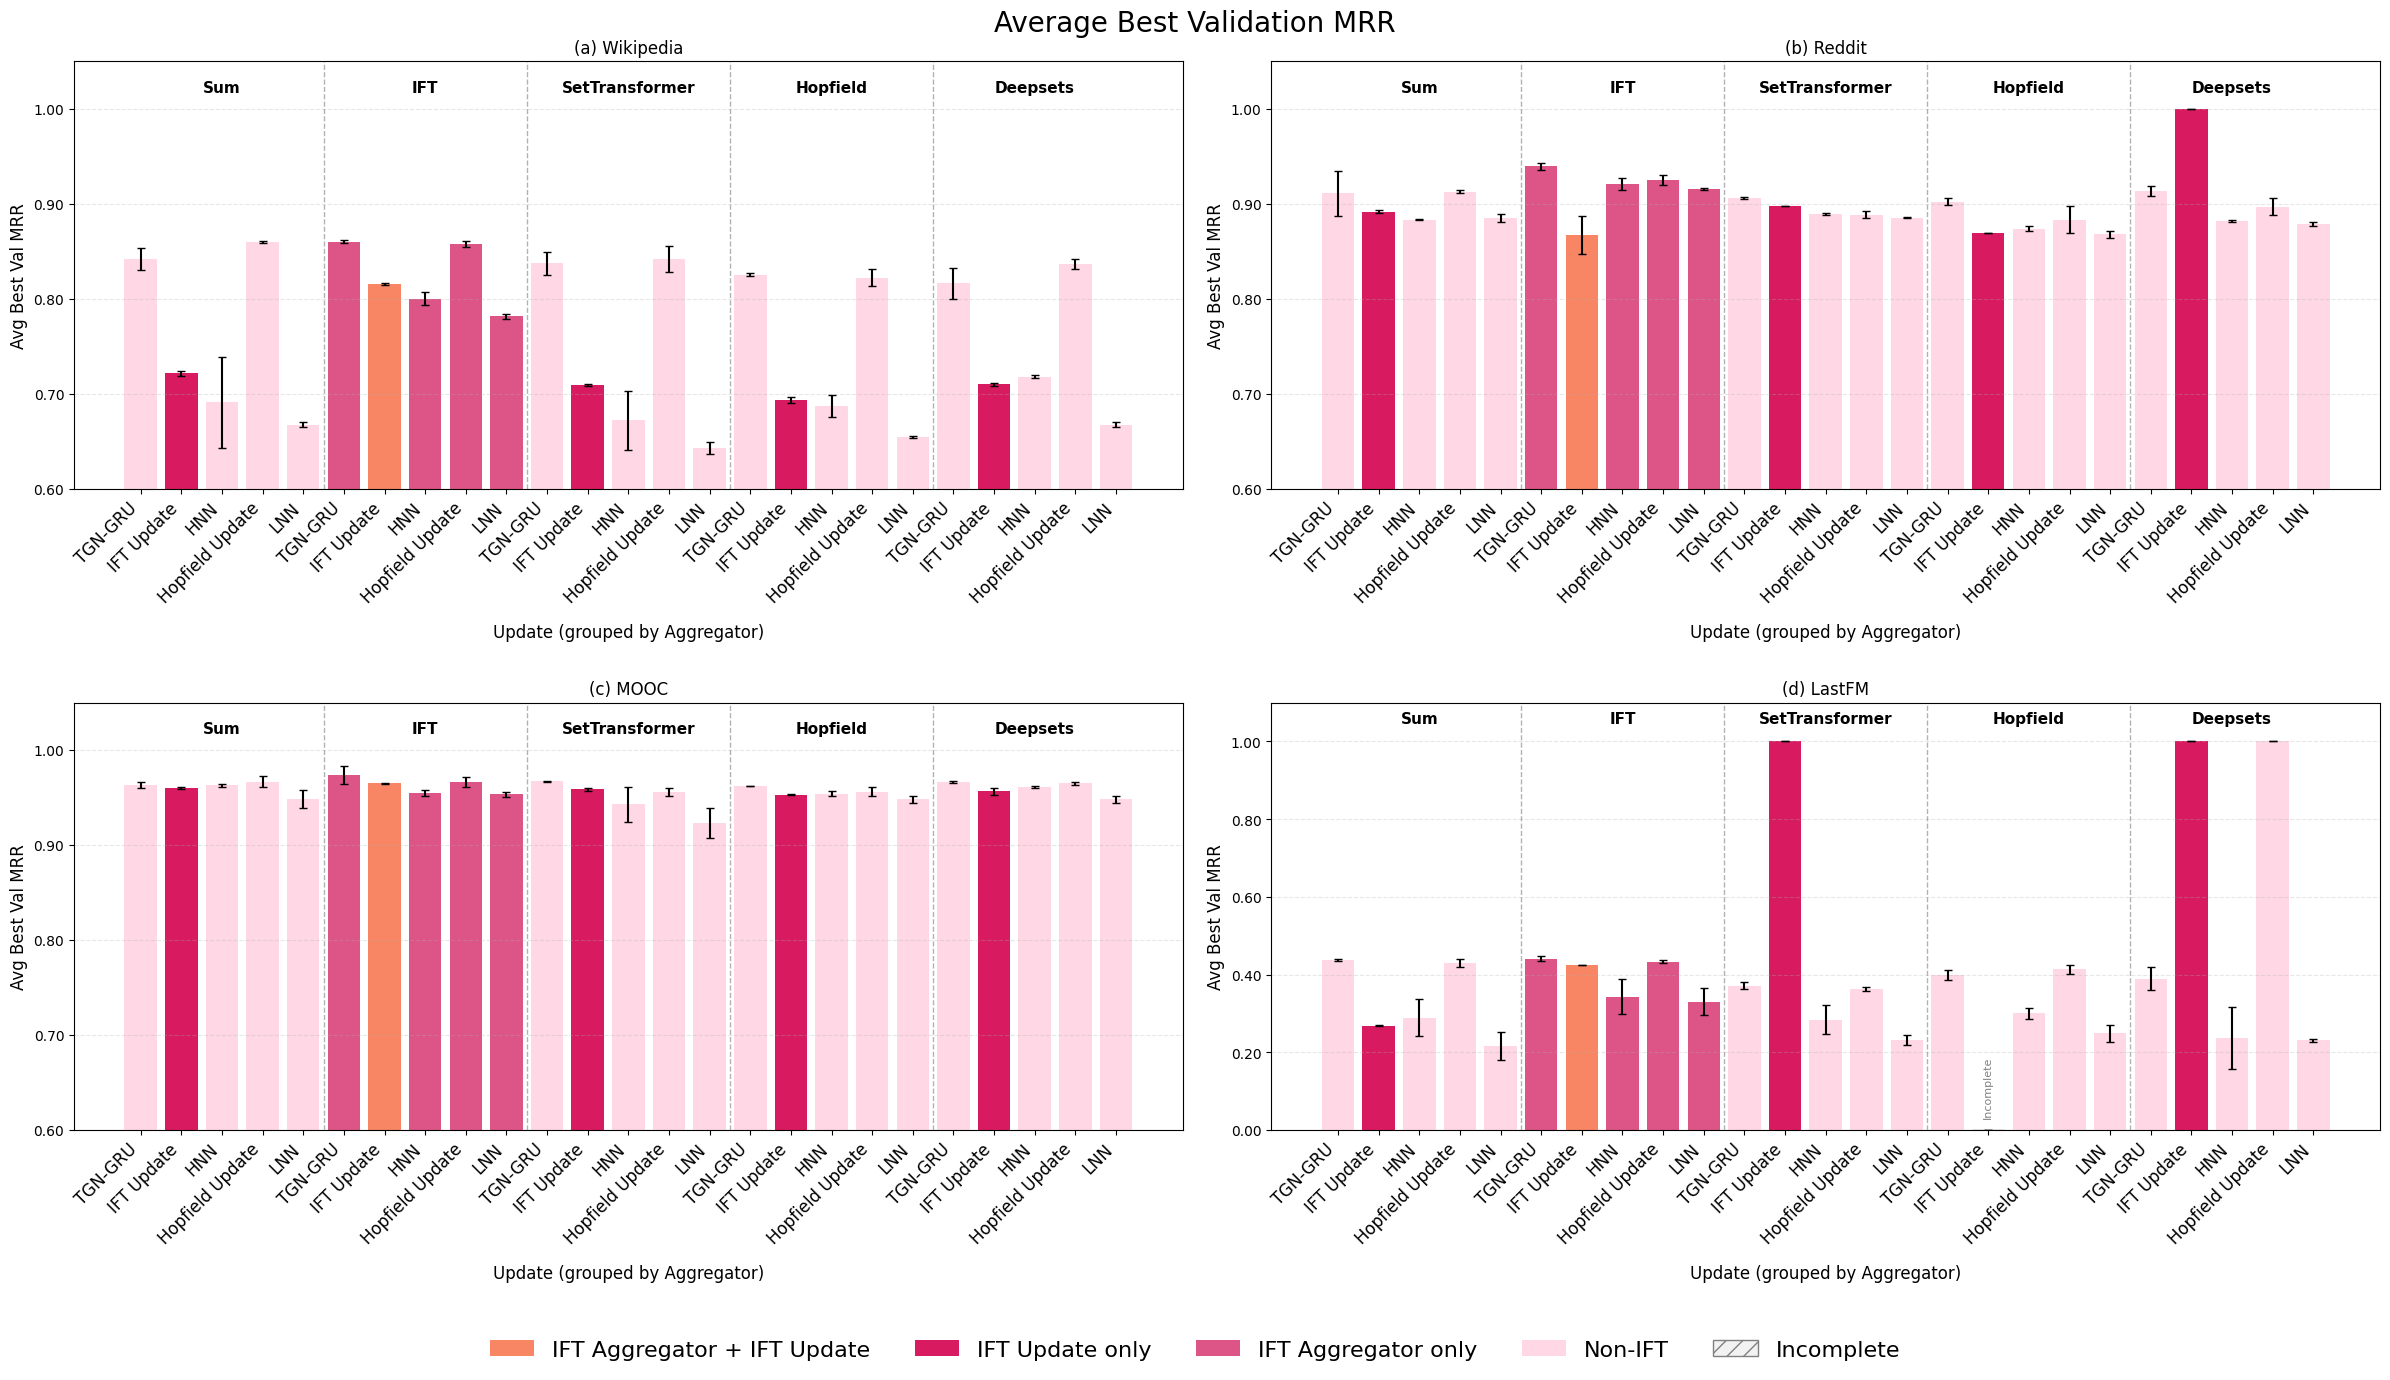

In [248]:
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter

fig, axes = plt.subplots(2, 2, figsize=(24, 14), sharey=False)
axes = axes.flatten()

AGG_ORDER = ["sum", "ift", "settransformer", "hopfield", "deepsets"]
UPD_ORDER = ["tgn_gru", "ift_update", "hnn", "hopfield_update", "lnn"]

def pretty_name(agg, upd):
    agg_map = {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }
    upd_map = {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }
    return f"{agg_map.get(agg, agg)} / {upd_map.get(upd, upd)}"

labels_abcd = ["(a)", "(b)", "(c)", "(d)"]

# full expected combo grid
full_index = pd.MultiIndex.from_product(
    [AGG_ORDER, UPD_ORDER],
    names=["aggregator", "update"]
)
full_df = pd.DataFrame(index=full_index).reset_index()

for ax, ds, panel_label in zip(axes, DATASET_ORDER, labels_abcd):
    df = rank_all_by_dataset[ds].copy()

    # merge actual results onto full combo list
    df_full = full_df.merge(df, on=["aggregator", "update"], how="left")

    # preserve explicit ordering
    df_full["aggregator"] = pd.Categorical(df_full["aggregator"], categories=AGG_ORDER, ordered=True)
    df_full["update"] = pd.Categorical(df_full["update"], categories=UPD_ORDER, ordered=True)
    df_full = df_full.sort_values(["aggregator", "update"]).reset_index(drop=True)

    x = np.arange(len(df_full))
    y = df_full["avg_val_mrr"].values
    err = df_full["std_val_mrr"].fillna(0).values
    labels = [pretty_upd(u) for u in df_full["update"]]

    # missing bars should still occupy space
    bar_heights = np.nan_to_num(y, nan=0.0)

    bars = ax.bar(x, bar_heights, yerr=err, capsize=3)

    for i, (bar, upd, agg, val) in enumerate(zip(bars, df_full["update"], df_full["aggregator"], y)):
        if pd.isna(val):
            # incomplete combo
            bar.set_facecolor("#f2f2f2")
            bar.set_edgecolor("gray")
            bar.set_hatch("//")
            bar.set_linewidth(1.0)

            # mark incomplete above baseline
            ax.text(
                i, 0.62 if ds in ["Wikipedia", "Reddit", "MOOC"] else 0.03,
                "Incomplete",
                rotation=90,
                ha="center",
                va="bottom",
                fontsize=8,
                color="gray"
            )
        else:
            if (upd == "ift_update") and (agg == "ift"):
                bar.set_facecolor("#f88664")
            elif upd == "ift_update":
                bar.set_facecolor("#d81b60")
            elif agg == "ift":
                bar.set_facecolor("#dd5486")
            else:
                bar.set_facecolor("#ffd7e5")

    # separator lines between aggregator groups
    for boundary in [4.5, 9.5, 14.5, 19.5]:
        ax.axvline(boundary, color="gray", linestyle="--", linewidth=1, alpha=0.6)

    # optional group labels centered over each block of 5
    group_centers = [2, 7, 12, 17, 22]
    group_names = ["Sum", "IFT", "SetTransformer", "Hopfield", "Deepsets"]
    for xc, gname in zip(group_centers, group_names):
        ax.text(
            xc,
            1.015 if ds in ["Wikipedia", "Reddit", "MOOC"] else 1.04,
            gname,
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    ax.set_title(f"{panel_label} {ds}")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=12)
    ax.set_ylabel("Avg Best Val MRR", fontsize=12)
    ax.set_xlabel("Update (grouped by Aggregator)", fontsize=12, labelpad=12)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    if ds in ["Wikipedia", "Reddit", "MOOC"]:
        ax.set_ylim(0.6, 1.05)
    elif ds == "LastFM":
        ax.set_ylim(0.0, 1.1)

legend_elements = [
    Patch(facecolor="#f88664", label="IFT Aggregator + IFT Update"),
    Patch(facecolor="#d81b60", label="IFT Update only"),
    Patch(facecolor="#dd5486", label="IFT Aggregator only"),
    Patch(facecolor="#ffd7e5", label="Non-IFT"),
    Patch(facecolor="#f2f2f2", edgecolor="gray", hatch="//", label="Incomplete"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=16
)

fig.suptitle("Average Best Validation MRR", fontsize=20)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.subplots_adjust(
    hspace=0.5,   # vertical spacing between rows
    wspace=0.08    # horizontal spacing between columns
)
fig.savefig(PLOTS_DIR / "grouped_by_aggregator_bar_with_incomplete.png", dpi=300, bbox_inches="tight")
plt.show()

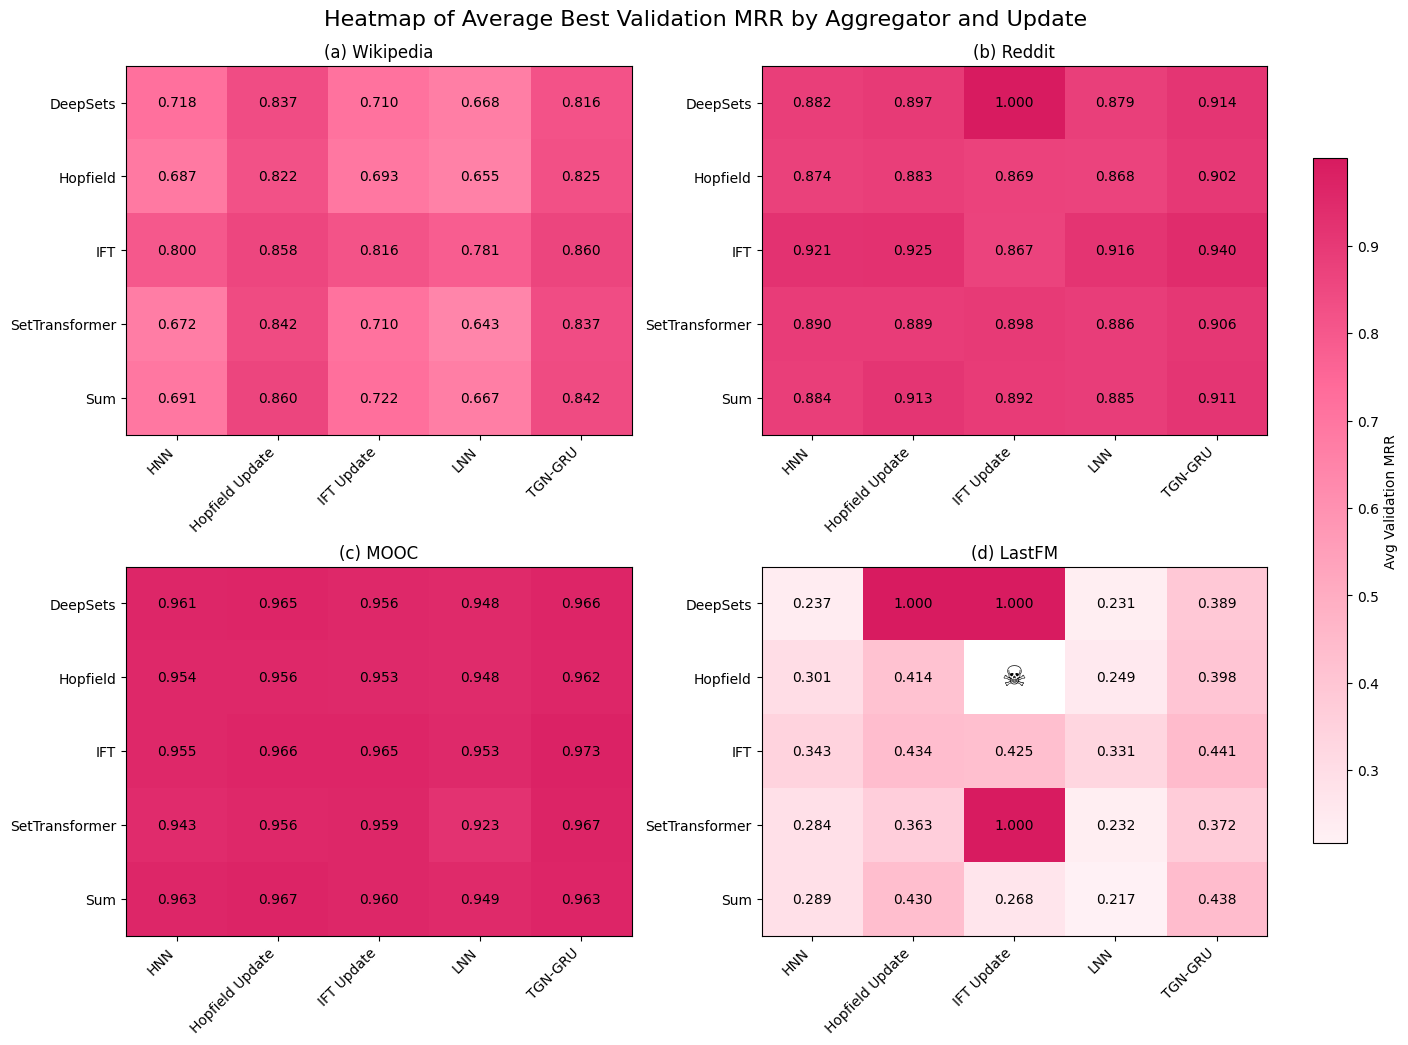

In [249]:
from matplotlib.colors import LinearSegmentedColormap

def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

# custom pink colormap
pink_cmap = LinearSegmentedColormap.from_list(
    "pinkmap",
    ["#fff1f5", "#ffb3c6", "#ff6b9a", "#d81b60"]
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()

labels = ["(a)", "(b)", "(c)", "(d)"]

global_vmin = plot_df["avg_val_mrr"].min()
global_vmax = plot_df["avg_val_mrr"].max()

for ax, ds, label in zip(axes, DATASET_ORDER, labels):

    df = rank_all_by_dataset[ds].copy()

    heat = df.pivot(
        index="aggregator",
        columns="update",
        values="avg_val_mrr"
    )

    im = ax.imshow(
        heat.values,
        aspect="auto",
        vmin=global_vmin,
        vmax=global_vmax,
        cmap=pink_cmap
    )

    ax.set_title(f"{label} {ds}")

    # prettier labels
    clean_updates = [pretty_upd(c) for c in heat.columns]
    clean_aggs = [pretty_agg(a) for a in heat.index]

    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels(clean_updates, rotation=45, ha="right")

    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(clean_aggs)
    # annotate cells
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.values[i, j]
            if pd.notna(val):
                text = f"{val:.3f}"
                color = "black"
                size = 10
            else:
                text = "☠️"
                size = 20

            ax.text(
                j, i,
                text,
                ha="center",
                va="center",
                fontsize=size,
                color=color
            )
                

# put colorbar on the right side of the figure
cbar = fig.colorbar(
    im,
    ax=axes,
    location="right",
    fraction=0.03,
    pad=0.04
)

cbar.set_label("Avg Validation MRR")

fig.suptitle("Heatmap of Average Best Validation MRR by Aggregator and Update", fontsize=16, y=1.03)
fig.savefig(
    PLOTS_DIR / "heatmap_avg_val_mrr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

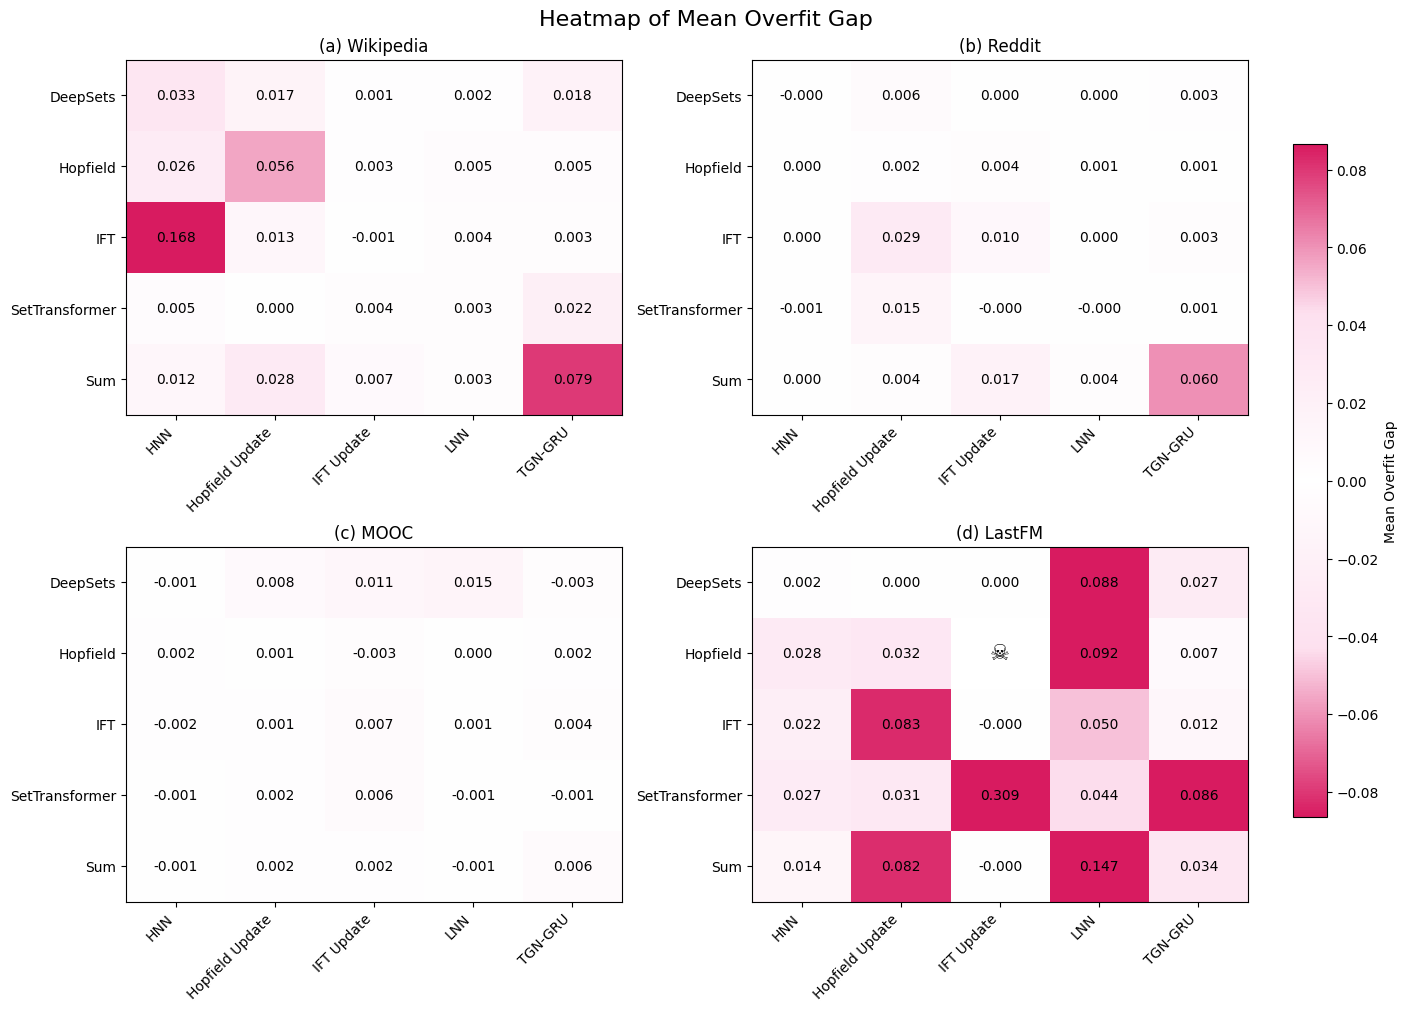

In [271]:
from matplotlib.colors import LinearSegmentedColormap

# 🔹 pretty names (same as before)
def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

# 🔥 diverging pink colormap (negative → light, positive → dark)
diverging_pink = LinearSegmentedColormap.from_list(
    "diverging_pink",
    ["#d81b60", "#fde0ef", "#ffffff", "#fde0ef", "#d81b60"]  # light pink → white → dark pink
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()

labels = ["(a)", "(b)", "(c)", "(d)"]

# 🔹 symmetric scale around 0
absmax = np.nanpercentile(
    np.abs(plot_df["mean_overfit_gap"].values),
    95   # or 90 if you want stronger clipping
)
global_vmin = -absmax
global_vmax = absmax

for ax, ds, label in zip(axes, DATASET_ORDER, labels):

    df = rank_all_by_dataset[ds].copy()

    heat = df.pivot(
        index="aggregator",
        columns="update",
        values="mean_overfit_gap"
    )

    im = ax.imshow(
        heat.values,
        aspect="auto",
        vmin=global_vmin,
        vmax=global_vmax,
        cmap=diverging_pink
    )

    ax.set_title(f"{label} {ds}")

    # ✅ same pretty labels
    clean_updates = [pretty_upd(c) for c in heat.columns]
    clean_aggs = [pretty_agg(a) for a in heat.index]

    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels(clean_updates, rotation=45, ha="right")

    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(clean_aggs)

    # 🔹 annotate cells
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.values[i, j]

            if pd.notna(val):
                text = f"{val:.3f}"

                # white text on darker cells
                color = "black"
                size = 10
            else:
                text = "☠️"
                color = "black"
                size = 16

            ax.text(
                j, i,
                text,
                ha="center",
                va="center",
                fontsize=size,
                color=color
            )

# 🔹 clean colorbar (RIGHT SIDE, same as before)
cbar = fig.colorbar(
    im,
    ax=axes,
    location="right",
    fraction=0.03,
    pad=0.04
)

cbar.set_label("Mean Overfit Gap")

fig.suptitle(
    "Heatmap of Mean Overfit Gap",
    fontsize=16
)

fig.savefig(
    PLOTS_DIR / "heatmap_mean_overfit_gap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

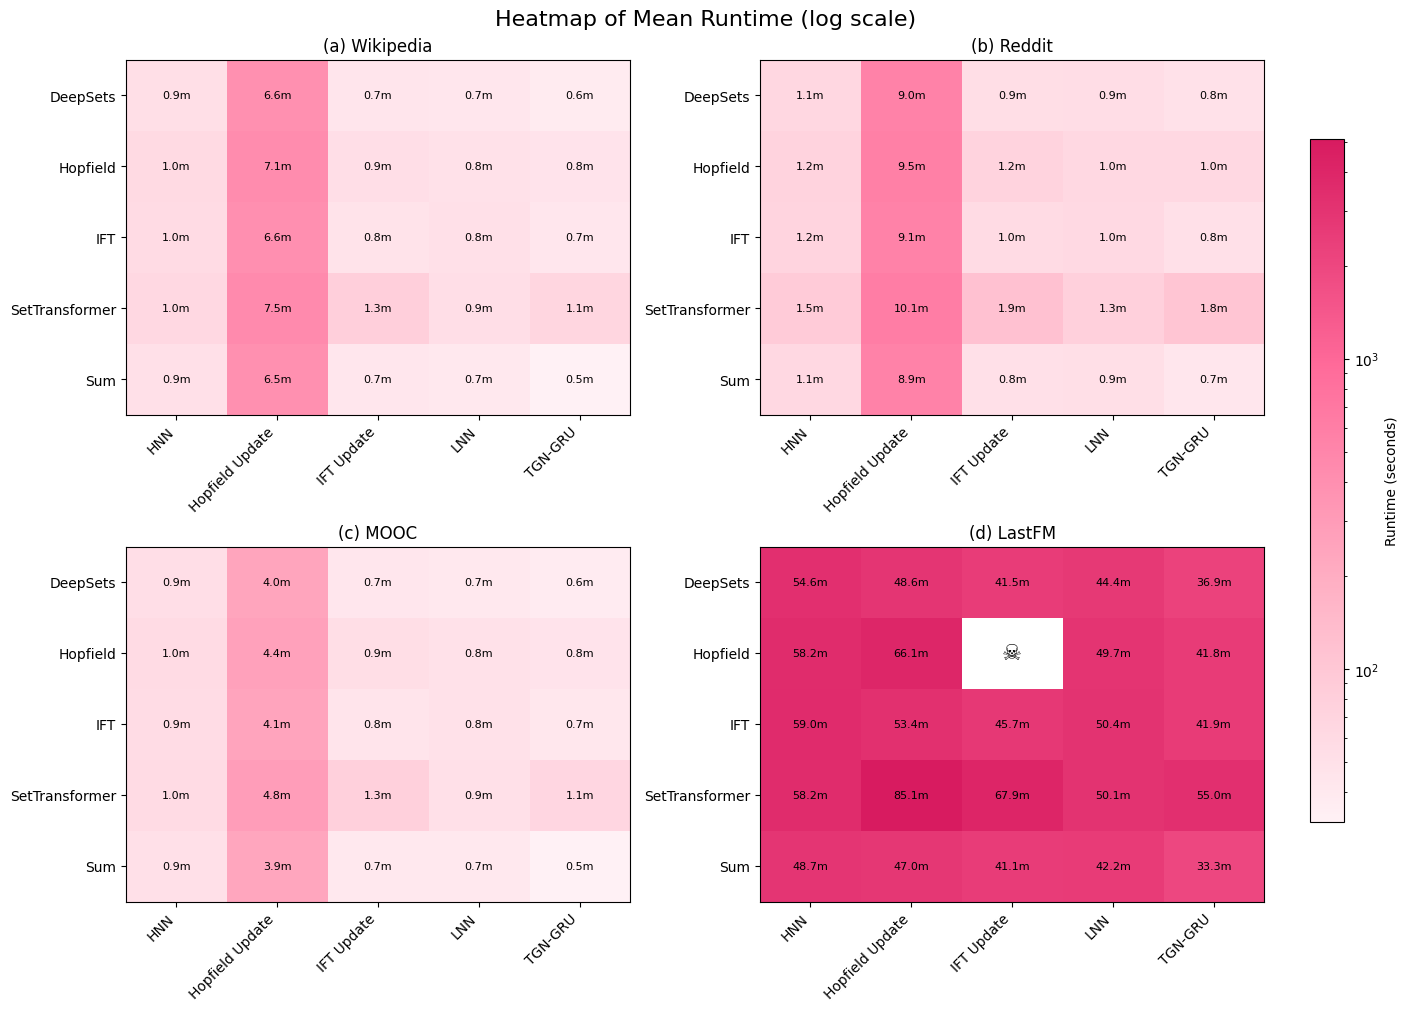

In [251]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as colors

# 🔹 pretty names (reuse)
def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

# 💖 sequential pink colormap (low → high runtime)
pink_cmap = LinearSegmentedColormap.from_list(
    "pink_runtime",
    ["#fff1f5", "#ffb3c6", "#ff6b9a", "#d81b60"]
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()

labels = ["(a)", "(b)", "(c)", "(d)"]

# 🔹 global scale (keeps comparison fair)
global_vmin = plot_df["wall_sec_mean"].min()
global_vmax = plot_df["wall_sec_mean"].max()

for ax, ds, label in zip(axes, DATASET_ORDER, labels):

    df = rank_all_by_dataset[ds].copy()

    heat = df.pivot(
        index="aggregator",
        columns="update",
        values="wall_sec_mean"
    )

    im = ax.imshow(
        heat.values,
        norm=colors.LogNorm(vmin=global_vmin, vmax=global_vmax),
        cmap=pink_cmap,
        aspect="auto"
    )

    ax.set_title(f"{label} {ds}")

    # ✅ consistent pretty labels
    clean_updates = [pretty_upd(c) for c in heat.columns]
    clean_aggs = [pretty_agg(a) for a in heat.index]

    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels(clean_updates, rotation=45, ha="right")

    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(clean_aggs)

    # 🔹 annotate (minutes, black text only)
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.values[i, j]

            if pd.notna(val):
                text = f"{val/60:.1f}m"   # convert sec → minutes
                size = 8
            else:
                text = "☠️"
                size = 16

            ax.text(
                j, i,
                text,
                ha="center",
                va="center",
                fontsize=size,
                color="black"
            )

# 🔹 clean right-side colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    location="right",
    fraction=0.03,
    pad=0.04
)

cbar.set_label("Runtime (seconds)")

fig.suptitle(
    "Heatmap of Mean Runtime (log scale)",
    fontsize=16
)

fig.savefig(
    PLOTS_DIR / "heatmap_runtime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

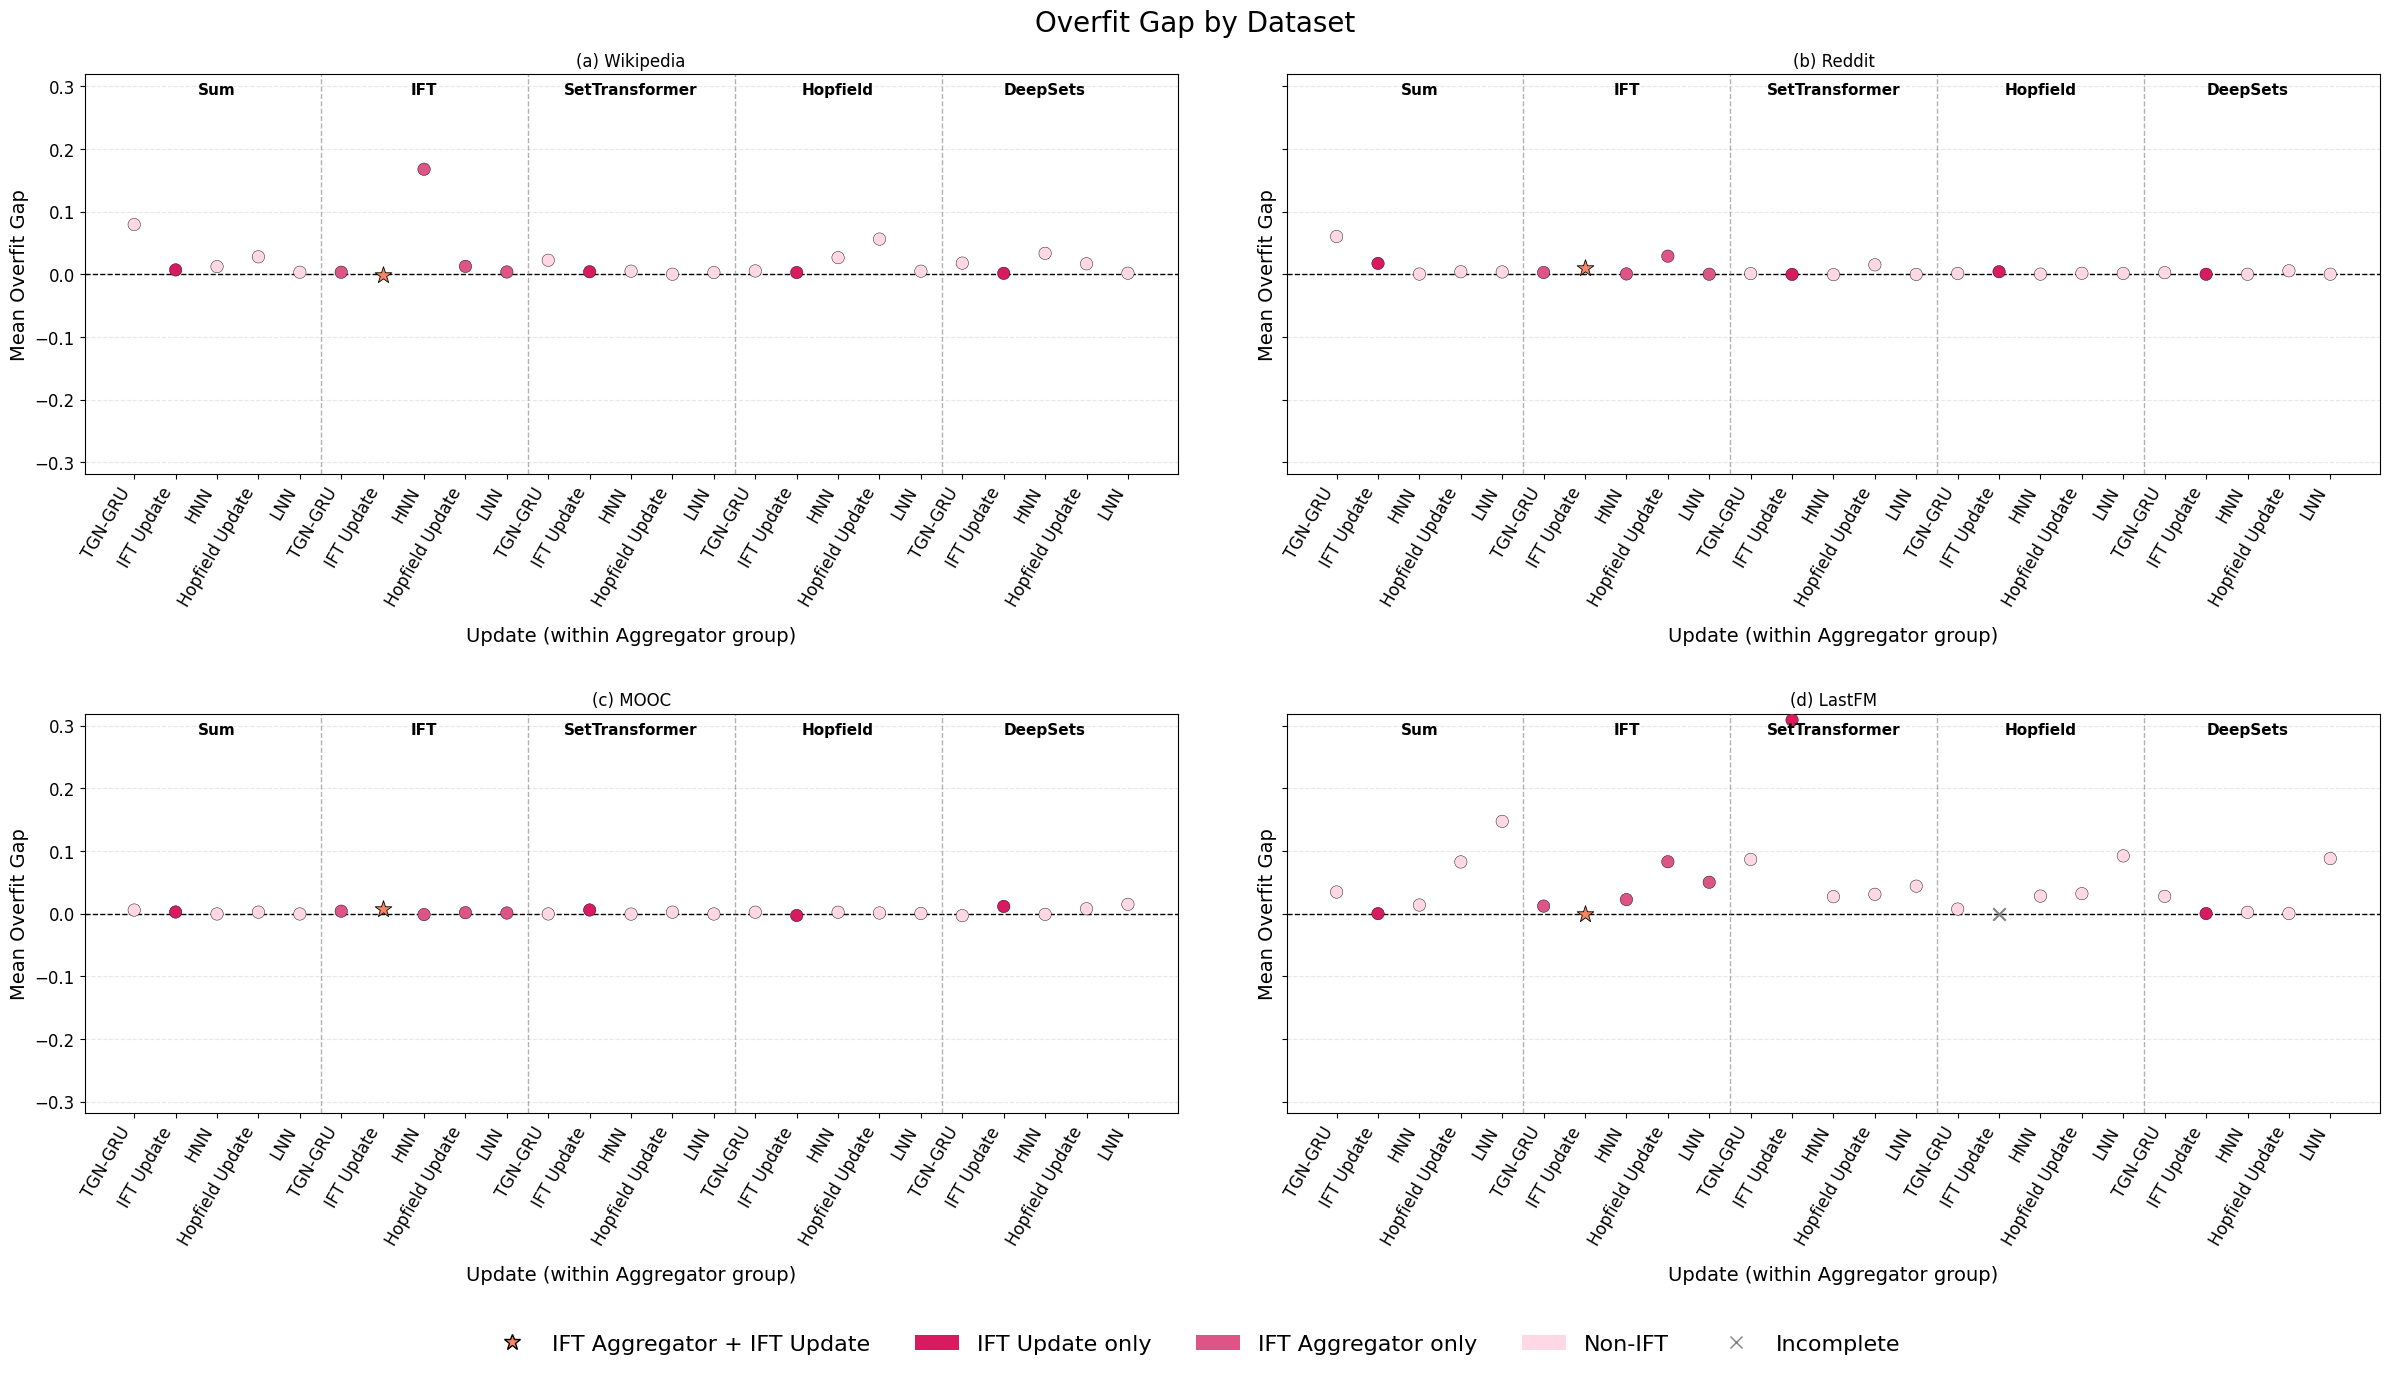

In [252]:
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter
from matplotlib.lines import Line2D
def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

AGG_ORDER = ["sum", "ift", "settransformer", "hopfield", "deepsets"]
UPD_ORDER = ["tgn_gru", "ift_update", "hnn", "hopfield_update", "lnn"]

fig, axes = plt.subplots(2, 2, figsize=(24, 15), sharey=True)
axes = axes.flatten()

labels_abcd = ["(a)", "(b)", "(c)", "(d)"]

absmax = np.nanmax(np.abs(plot_df["mean_overfit_gap"].values))
ymin, ymax = -absmax - 0.01, absmax + 0.01

# full combo grid so missing combos still appear
full_index = pd.MultiIndex.from_product(
    [AGG_ORDER, UPD_ORDER],
    names=["aggregator", "update"]
)
full_df = pd.DataFrame(index=full_index).reset_index()

for ax, ds, panel_label in zip(axes, DATASET_ORDER, labels_abcd):
    df = rank_all_by_dataset[ds].copy()

    # merge onto full combo grid
    df_full = full_df.merge(df, on=["aggregator", "update"], how="left")

    df_full["aggregator"] = pd.Categorical(
        df_full["aggregator"], categories=AGG_ORDER, ordered=True
    )
    df_full["update"] = pd.Categorical(
        df_full["update"], categories=UPD_ORDER, ordered=True
    )
    df_full = df_full.sort_values(["aggregator", "update"]).reset_index(drop=True)

    x = np.arange(len(df_full))
    y = df_full["mean_overfit_gap"].values
    labels = [pretty_upd(u) for u in df_full["update"]]

    colors = [
        "#f88664" if (u == "ift_update" and a == "ift")
        else "#d81b60" if (u == "ift_update")
        else "#dd5486" if (a == "ift")
        else "#ffd7e5"
        for a, u in zip(df_full["aggregator"], df_full["update"])
    ]

    # plot completed points
    mask = pd.notna(y)
    # identify special combo
    is_star = (df_full["aggregator"] == "ift") & (df_full["update"] == "ift_update")
    is_star = is_star.values & mask

    # normal points
    normal_mask = mask & ~is_star

    ax.scatter(
        x[normal_mask],
        y[normal_mask],
        c=np.array(colors)[normal_mask],
        s=80,
        edgecolors="black",
        linewidth=0.3,
        marker="o",
        zorder=3
    )

    # ⭐ star points
    ax.scatter(
        x[is_star],
        y[is_star],
        c="#f88664",   # same highlight color
        s=160,         # bigger so it stands out
        edgecolors="black",
        linewidth=0.6,
        marker="*",
        zorder=4
    )

    # plot incomplete combos as gray X on the zero line
    incomplete_mask = ~mask
    if incomplete_mask.any():
        ax.scatter(
            x[incomplete_mask],
            np.zeros(incomplete_mask.sum()),
            marker="x",
            s=80,
            color="gray",
            linewidth=1.5,
            zorder=3
        )

    ax.axhline(0, linestyle="--", color="black", linewidth=1)
    ax.set_title(f"{panel_label} {ds}")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=60, ha="right")
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel("Mean Overfit Gap", fontsize=14)
    ax.set_xlabel("Update (within Aggregator group)", fontsize=14, labelpad=12)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # separator lines between aggregator groups
    for boundary in [4.5, 9.5, 14.5, 19.5]:
        ax.axvline(boundary, color="gray", linestyle="--", linewidth=1, alpha=0.6)

    # aggregator headers above each block
    group_centers = [2, 7, 12, 17, 22]
    group_names = [pretty_agg(a) for a in AGG_ORDER]

    for xc, gname in zip(group_centers, group_names):
        ax.text(
            xc,
            ymax - 0.02 * (ymax - ymin),   # 👈 inside plot near top
            gname,
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold"
        )

legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='#f88664', markeredgecolor='black', markersize=12, label="IFT Aggregator + IFT Update"),
    Patch(facecolor="#d81b60", label="IFT Update only"),
    Patch(facecolor="#dd5486", label="IFT Aggregator only"),
    Patch(facecolor="#ffd7e5", label="Non-IFT"),
    Line2D([0], [0], marker="x", color="gray", linestyle="None", markersize=8, label="Incomplete"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=5,
    frameon=False,
    fontsize=16
)

fig.suptitle("Overfit Gap by Dataset", fontsize=20, y=.94)
fig.tight_layout(rect=[0, 0.08, 1, 0.95])
fig.subplots_adjust(
    hspace=0.6,   # vertical spacing between rows
    wspace=0.1    # horizontal spacing between columns
)
fig.savefig(PLOTS_DIR / "overfit_gap_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

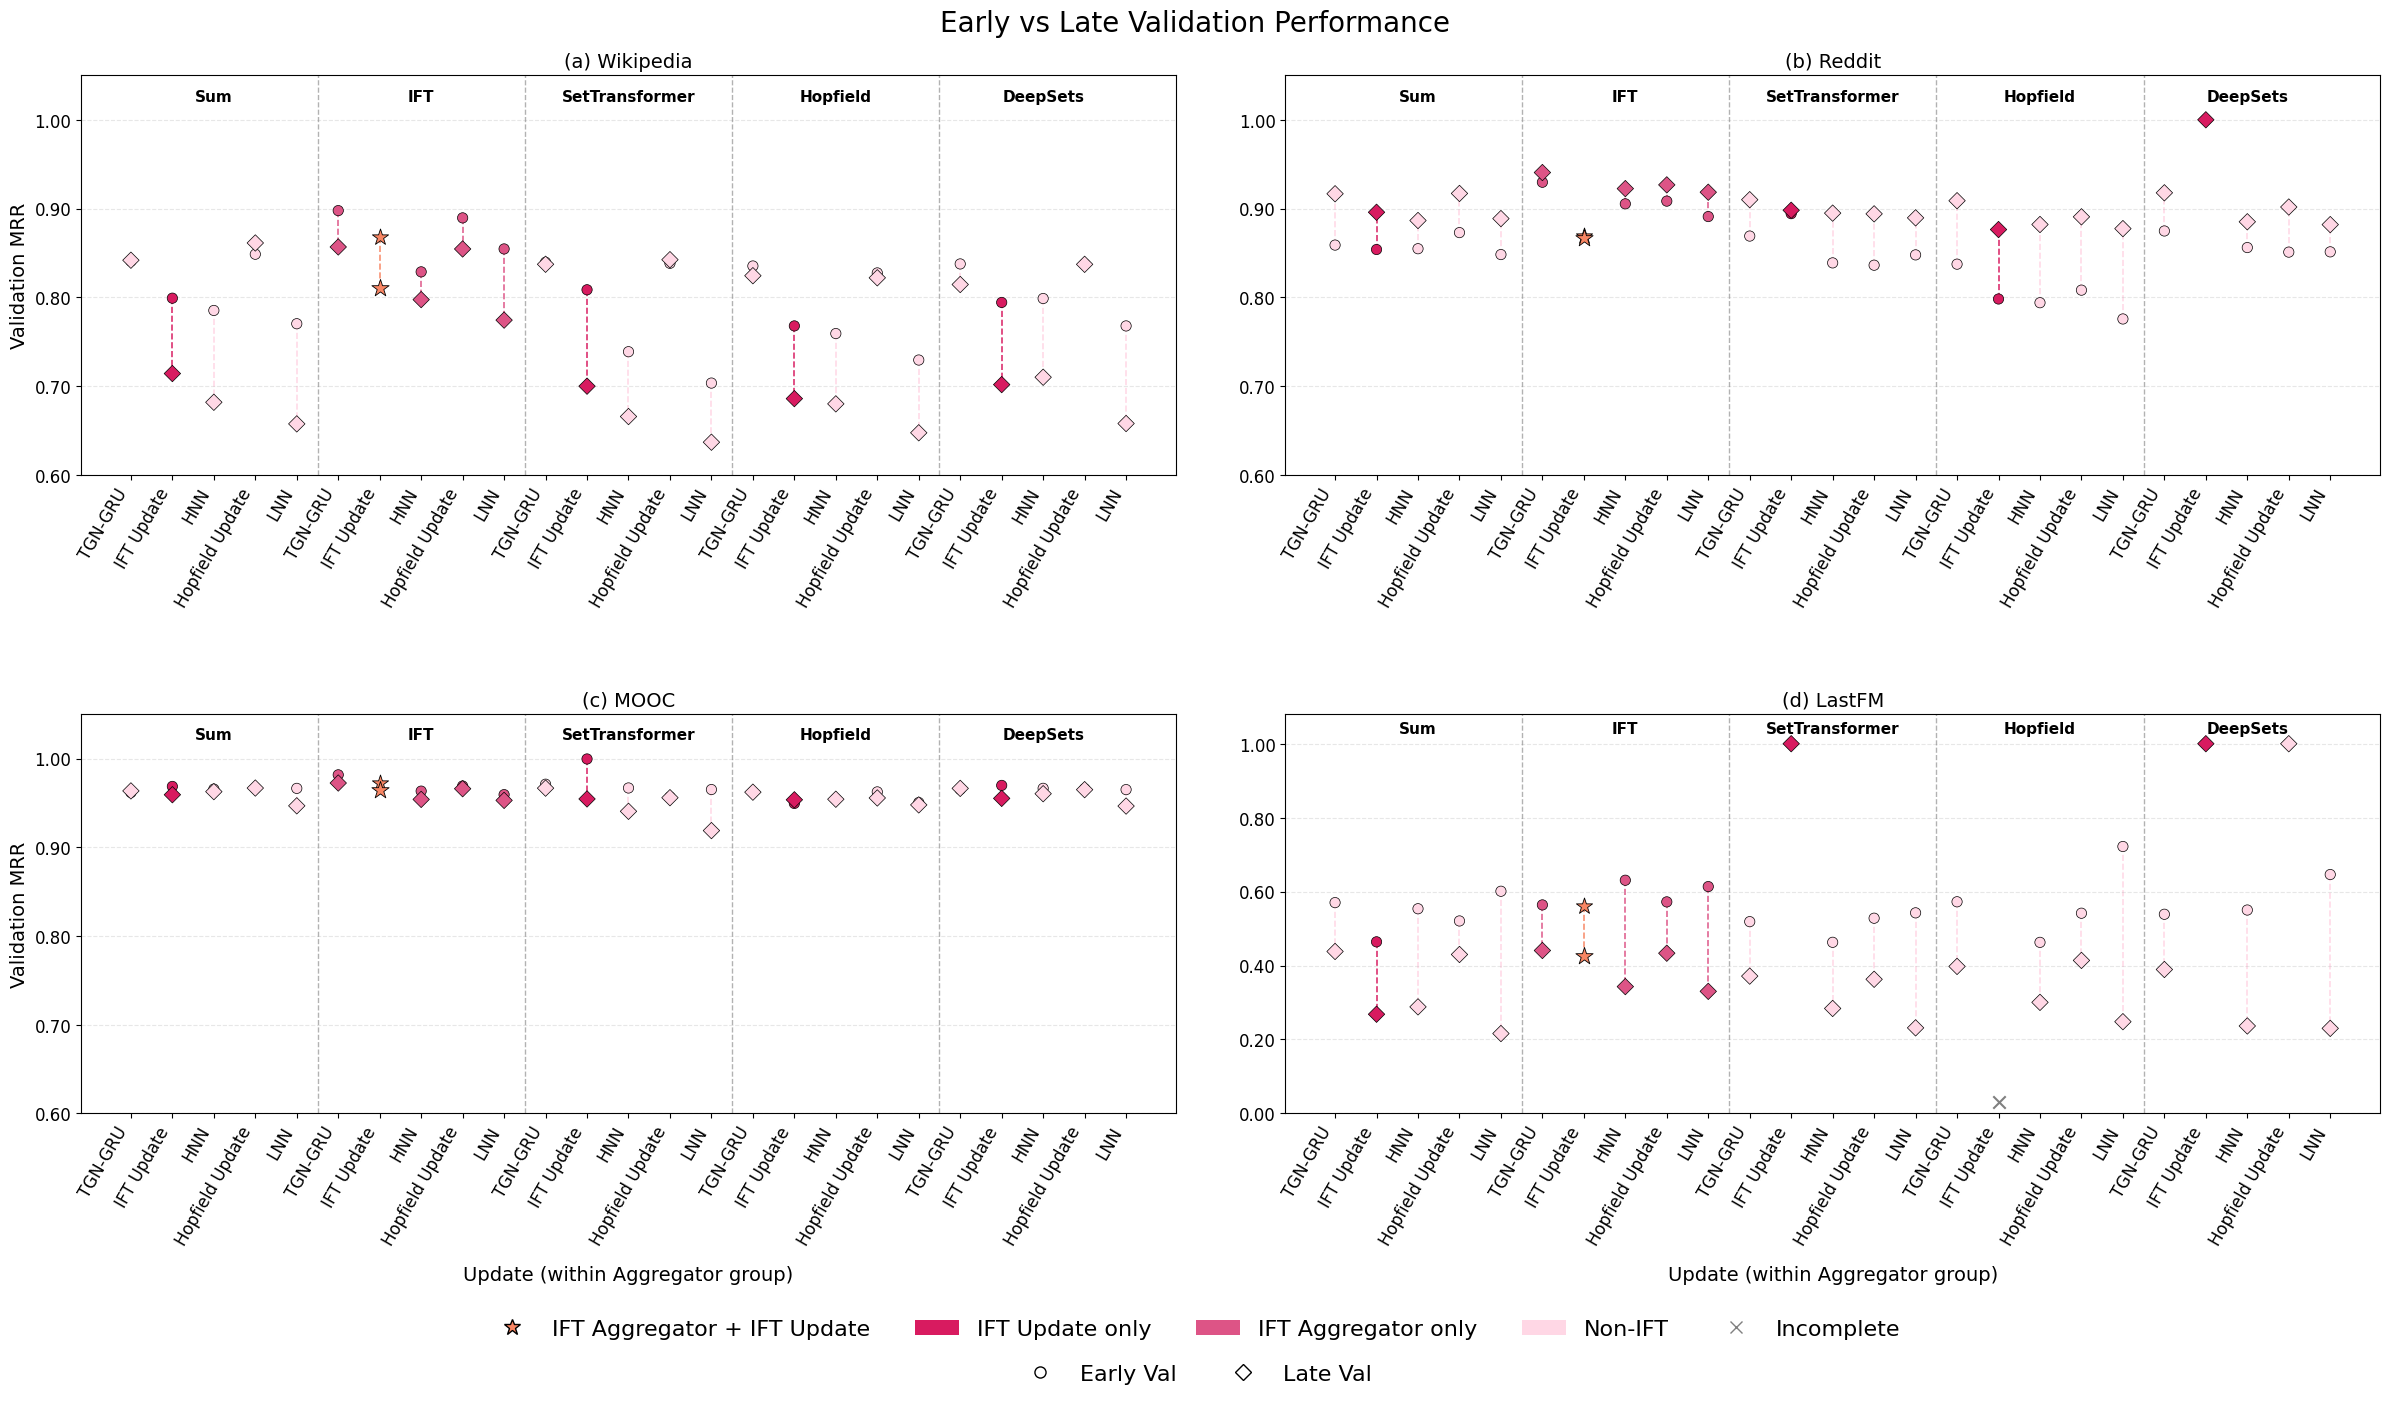

In [253]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter

def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

AGG_ORDER = ["sum", "ift", "settransformer", "hopfield", "deepsets"]
UPD_ORDER = ["tgn_gru", "ift_update", "hnn", "hopfield_update", "lnn"]

fig, axes = plt.subplots(2, 2, figsize=(24, 15), sharey=False)
axes = axes.flatten()

labels_abcd = ["(a)", "(b)", "(c)", "(d)"]

# full combo grid so missing combos still appear
full_index = pd.MultiIndex.from_product(
    [AGG_ORDER, UPD_ORDER],
    names=["aggregator", "update"]
)
full_df = pd.DataFrame(index=full_index).reset_index()

for ax, ds, panel_label in zip(axes, DATASET_ORDER, labels_abcd):
    df = rank_all_by_dataset[ds].copy()

    # merge onto full combo grid
    df_full = full_df.merge(df, on=["aggregator", "update"], how="left")

    df_full["aggregator"] = pd.Categorical(
        df_full["aggregator"], categories=AGG_ORDER, ordered=True
    )
    df_full["update"] = pd.Categorical(
        df_full["update"], categories=UPD_ORDER, ordered=True
    )
    df_full = df_full.sort_values(["aggregator", "update"]).reset_index(drop=True)

    x = np.arange(len(df_full))
    early = df_full["avg_early_val_mrr"].values
    late = df_full["avg_late_val_mrr"].values
    labels = [pretty_upd(u) for u in df_full["update"]]

    combo_colors = [
        "#f88664" if (u == "ift_update" and a == "ift")
        else "#d81b60" if (u == "ift_update")
        else "#dd5486" if (a == "ift")
        else "#ffd7e5"
        for a, u in zip(df_full["aggregator"], df_full["update"])
    ]

    # masks
    early_mask = pd.notna(early)
    late_mask = pd.notna(late)
    complete_mask = early_mask & late_mask

    is_star = (
        (df_full["aggregator"] == "ift") &
        (df_full["update"] == "ift_update")
    ).values

    normal_complete = complete_mask & ~is_star
    star_complete = complete_mask & is_star
    incomplete_mask = ~(early_mask & late_mask)

    # connector lines for complete combos only
    for i in np.where(complete_mask)[0]:
        ax.plot(
            [x[i], x[i]],
            [early[i], late[i]],
            color=combo_colors[i],
            linewidth=1.2,
            linestyle="--",
            alpha=0.9,
            zorder=1
        )

    # normal early points
    ax.scatter(
        x[normal_complete],
        early[normal_complete],
        c=np.array(combo_colors)[normal_complete],
        s=55,
        edgecolors="black",
        linewidth=0.5,
        marker="o",
        zorder=3
    )

    # normal late points
    ax.scatter(
        x[normal_complete],
        late[normal_complete],
        c=np.array(combo_colors)[normal_complete],
        s=70,
        edgecolors="black",
        linewidth=0.5,
        marker="D",
        zorder=3
    )

    # star combo early
    ax.scatter(
        x[star_complete],
        early[star_complete],
        c="#f88664",
        s=150,
        edgecolors="black",
        linewidth=0.6,
        marker="*",
        zorder=4
    )

    # star combo late
    ax.scatter(
        x[star_complete],
        late[star_complete],
        c="#f88664",
        s=170,
        edgecolors="black",
        linewidth=0.6,
        marker="*",
        zorder=4
    )

    # incomplete combos shown as gray X near bottom
    if incomplete_mask.any():
        y_incomplete = np.full(incomplete_mask.sum(), 0.62 if ds in ["Wikipedia", "Reddit", "MOOC"] else 0.03)
        ax.scatter(
            x[incomplete_mask],
            y_incomplete,
            marker="x",
            s=80,
            color="gray",
            linewidth=1.5,
            zorder=3
        )

    # y axis range
    if ds in ["Wikipedia", "Reddit", "MOOC"]:
        ax.set_ylim(0.6, 1.05)
        top_y = 1.035
    elif ds == "LastFM":
        ax.set_ylim(0.0, 1.08)
        top_y = 1.06

    ax.set_title(f"{panel_label} {ds}", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=60, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

    # only left column y-label
    if ax in [axes[0], axes[2]]:
        ax.set_ylabel("Validation MRR", fontsize=14)
    else:
        ax.set_ylabel("")

    # only bottom row x-label
    if ax in [axes[2], axes[3]]:
        ax.set_xlabel("Update (within Aggregator group)", fontsize=14, labelpad=12)
    else:
        ax.set_xlabel("")

    # separator lines between aggregator groups
    for boundary in [4.5, 9.5, 14.5, 19.5]:
        ax.axvline(boundary, color="gray", linestyle="--", linewidth=1, alpha=0.6)

    # aggregator labels inside plot
    group_centers = [2, 7, 12, 17, 22]
    group_names = [pretty_agg(a) for a in AGG_ORDER]

    for xc, gname in zip(group_centers, group_names):
        ax.text(
            xc,
            top_y,
            gname,
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold"
        )

# legends
model_color_legend = [
    Line2D([0], [0], marker="*", color="w",
           markerfacecolor="#f88664", markeredgecolor="black",
           markersize=12, label="IFT Aggregator + IFT Update"),
    Patch(facecolor="#d81b60", label="IFT Update only"),
    Patch(facecolor="#dd5486", label="IFT Aggregator only"),
    Patch(facecolor="#ffd7e5", label="Non-IFT"),
    Line2D([0], [0], marker="x", color="gray",
           linestyle="None", markersize=8, label="Incomplete"),
]

phase_legend = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="white",
           markeredgecolor="black", markersize=8, label="Early Val"),
    Line2D([0], [0], marker="D", color="none", markerfacecolor="white",
           markeredgecolor="black", markersize=8, label="Late Val"),
]

fig.legend(
    handles=model_color_legend,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.08),
    ncol=5,
    frameon=False,
    fontsize=16
)

fig.legend(
    handles=phase_legend,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=2,
    frameon=False,
    fontsize=16
)

fig.suptitle("Early vs Late Validation Performance", fontsize=20, y=0.94)
fig.tight_layout(rect=[0, 0.08, 1, 0.95])
fig.subplots_adjust(hspace=0.6, wspace=0.1)

fig.savefig(PLOTS_DIR / "early_vs_late_val_dumbbell_grouped.png", dpi=300, bbox_inches="tight")
plt.show()